# 03 — Análise exploratória do IMC

## 1. Objetivo

Descrever detalhadamente a distribuição do índice de massa corporal, estimar as prevalências de excesso de peso e obesidade e investigar possíveis valores extremos sem exclusão automática. A análise descreve a amostra estudada e não implica causalidade.

## 2. Importações

In [1]:
from hashlib import sha256
from pathlib import Path
import platform
import sys

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import skew

## 3. Configuração

In [2]:
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "pacientes_clean.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.plots import (
    plot_imc_boxplot,
    plot_imc_categories,
    plot_imc_distribution,
    plot_qq,
    save_figure,
)
from src.statistics import descriptive_numeric

PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "pacientes_clean.csv"
RAW_PATH = PROJECT_ROOT / "data" / "raw" / "sociodemografico.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
HISTOGRAM_PATH = FIGURES_DIR / "imc_histogram_density.png"
BOXPLOT_PATH = FIGURES_DIR / "imc_boxplot.png"
QQ_PATH = FIGURES_DIR / "imc_qqplot.png"
CATEGORY_PATH = FIGURES_DIR / "figure_1_imc_categories.png"
EXPECTED_RAW_SHA256 = "a895b5340c856d2cd1772c8e115ed5efc20f409d3aef5ecba14da23d44da9bf4"
IMC_CATEGORY_ORDER = [
    "Baixo peso", "Peso normal", "Sobrepeso", "Obesidade grau I",
    "Obesidade grau II", "Obesidade grau III",
]

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")

Python: 3.14.6
pandas: 3.0.5


## 4. Carregamento

Somente as variáveis analíticas necessárias são selecionadas. Nenhum identificador ou registro individual é exibido.

In [3]:
df = pd.read_csv(
    PROCESSED_PATH,
    usecols=["imc", "imc_categoria", "excesso_peso", "obesidade"],
)
imc = pd.to_numeric(df["imc"], errors="coerce")
imc_valid = imc.dropna()
print(f"Registros carregados: {len(df)}")

Registros carregados: 75


## 5. Validações

In [4]:
assert len(df) == 75
assert imc_valid.notna().all()
assert imc.isna().equals(df["imc_categoria"].isna())
assert imc.isna().equals(df["excesso_peso"].isna())
assert imc.isna().equals(df["obesidade"].isna())
assert set(df["imc_categoria"].dropna()).issubset(IMC_CATEGORY_ORDER)
assert sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_RAW_SHA256
print("IMC, categorias, indicadores e missing validados.")

IMC, categorias, indicadores e missing validados.


## 6. Análise

### 6.1 Estatísticas descritivas

In [5]:
imc_summary = descriptive_numeric(imc)
imc_skewness = float(skew(imc_valid, bias=False))
imc_summary_table = pd.DataFrame([{
    **imc_summary,
    "assimetria_fisher_pearson": imc_skewness,
}])
numeric_to_round = [
    "media", "desvio_padrao", "mediana", "p25", "p75",
    "minimo", "maximo", "assimetria_fisher_pearson",
]
imc_summary_table[numeric_to_round] = imc_summary_table[numeric_to_round].round(2)
display(imc_summary_table)

,n_valido,n_ausente,media,moda,desvio_padrao,mediana,p25,p75,minimo,maximo,observacoes,assimetria_fisher_pearson
0,73,2,28.72,29,5.5,27.94,24.62,32.3,17.5,41.1,,0.32


### 6.2 Categorias e prevalências

Os denominadores são os 73 pacientes com IMC válido. Missing não é convertido em ausência da condição.

In [6]:
category_counts = (
    df["imc_categoria"].value_counts().reindex(IMC_CATEGORY_ORDER, fill_value=0)
)
imc_category_table = pd.DataFrame({
    "categoria": IMC_CATEGORY_ORDER,
    "n": category_counts.to_numpy(),
    "percentual": (100 * category_counts / len(imc_valid)).round(2).to_numpy(),
})

n_excess_weight = int(imc_valid.ge(25).sum())
n_obesity = int(imc_valid.ge(30).sum())
imc_prevalence_table = pd.DataFrame({
    "indicador": ["Excesso de peso (IMC ≥25)", "Obesidade (IMC ≥30)"],
    "n_valido": [len(imc_valid), len(imc_valid)],
    "n": [n_excess_weight, n_obesity],
    "percentual": [
        round(100 * n_excess_weight / len(imc_valid), 2),
        round(100 * n_obesity / len(imc_valid), 2),
    ],
})
display(imc_category_table)
display(imc_prevalence_table)

,categoria,n,percentual
0,Baixo peso,3,4.11
1,Peso normal,18,24.66
2,Sobrepeso,26,35.62
3,Obesidade grau I,15,20.55
4,Obesidade grau II,9,12.33
5,Obesidade grau III,2,2.74


,indicador,n_valido,n,percentual
0,Excesso de peso (IMC ≥25),73,52,71.23
1,Obesidade (IMC ≥30),73,26,35.62


### 6.3 Extremos e plausibilidade

O critério de 1,5×IQR é usado somente para sinalização exploratória. A faixa de 10–80 kg/m² é uma barreira ampla de auditoria, não um critério de exclusão clínica.

In [7]:
q1 = imc_valid.quantile(0.25)
q3 = imc_valid.quantile(0.75)
iqr = q3 - q1
iqr_lower = q1 - 1.5 * iqr
iqr_upper = q3 + 1.5 * iqr
iqr_extreme = ~imc_valid.between(iqr_lower, iqr_upper)
biologically_implausible = ~imc_valid.between(10, 80)
n_iqr_extreme = int(iqr_extreme.sum())
n_implausible = int(biologically_implausible.sum())

extreme_summary = pd.DataFrame({
    "criterio": ["Limite inferior IQR", "Limite superior IQR", "Extremos IQR", "Fora da faixa ampla 10–80"],
    "valor": [round(iqr_lower, 2), round(iqr_upper, 2), n_iqr_extreme, n_implausible],
})
display(extreme_summary)

,criterio,valor
0,Limite inferior IQR,13.10
1,Limite superior IQR,43.82
2,Extremos IQR,0.00
3,Fora da faixa ampla 10–80,0.00


## 7. Visualizações

A densidade é apresentada porque há 73 observações válidas e 65 valores distintos. O Q-Q plot é interpretado em conjunto com histograma, boxplot e estatísticas numéricas; não determina automaticamente a escolha de testes futuros.

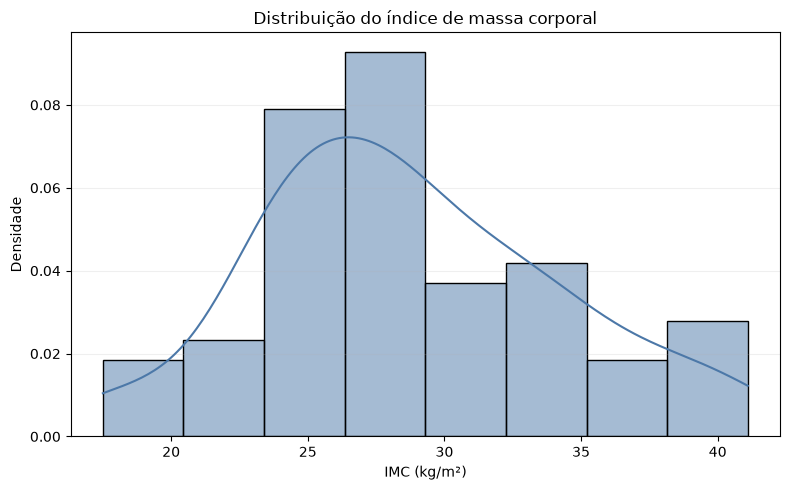

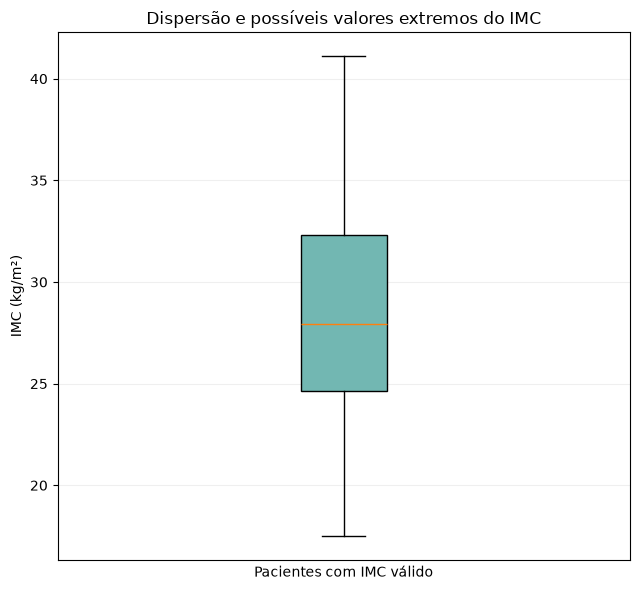

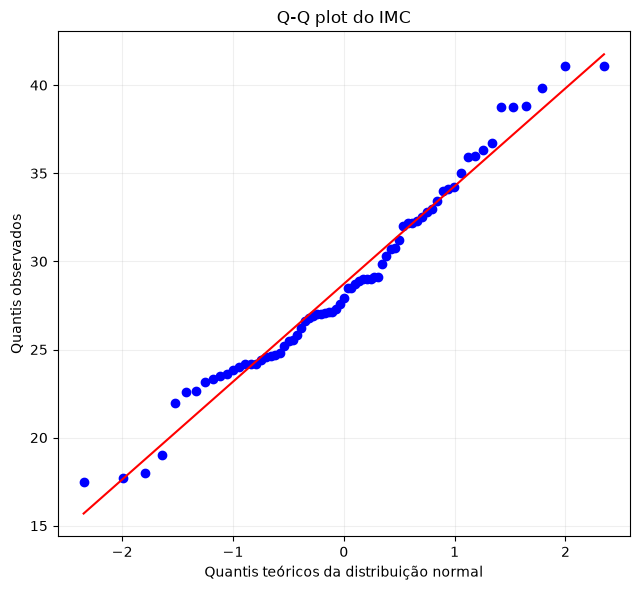

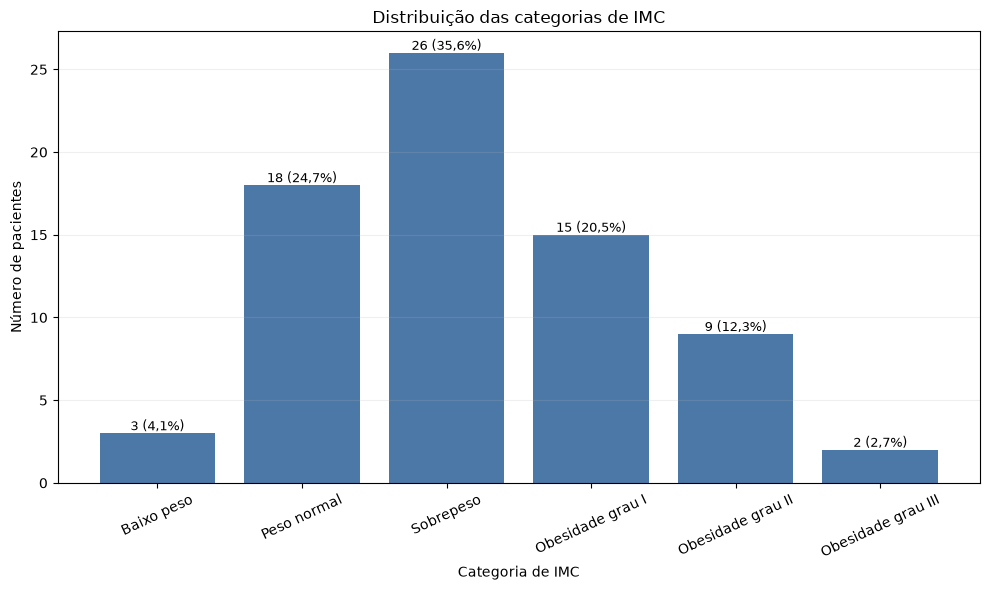

In [8]:
density_appropriate = len(imc_valid) >= 20 and imc_valid.nunique() >= 10
assert density_appropriate

histogram_figure, _ = plot_imc_distribution(imc_valid)
save_figure(histogram_figure, HISTOGRAM_PATH)
plt.show()

boxplot_figure, _ = plot_imc_boxplot(imc_valid)
save_figure(boxplot_figure, BOXPLOT_PATH)
plt.show()

qq_figure, _ = plot_qq(imc_valid, title="Q-Q plot do IMC")
save_figure(qq_figure, QQ_PATH)
plt.show()

category_figure, _ = plot_imc_categories(
    df["imc_categoria"], order=IMC_CATEGORY_ORDER
)
save_figure(category_figure, CATEGORY_PATH)
plt.show()

## 8. Conclusões deste notebook

In [9]:
if imc_skewness > 0:
    distribution_text = "leve assimetria à direita" if imc_skewness < 0.5 else "assimetria à direita"
elif imc_skewness < 0:
    distribution_text = "leve assimetria à esquerda" if imc_skewness > -0.5 else "assimetria à esquerda"
else:
    distribution_text = "assimetria aproximadamente nula"

print(f"IMC válido: {len(imc_valid)}")
print(f"IMC ausente: {imc.isna().sum()}")
print(
    f"Distribuição: {distribution_text} (coeficiente de assimetria = "
    f"{imc_skewness:.2f}); média discretamente superior à mediana."
)
print(
    f"Excesso de peso (IMC ≥25): {n_excess_weight}/{len(imc_valid)} "
    f"({100 * n_excess_weight / len(imc_valid):.2f}%)".replace(".", ",")
)
print(
    f"Obesidade (IMC ≥30): {n_obesity}/{len(imc_valid)} "
    f"({100 * n_obesity / len(imc_valid):.2f}%)".replace(".", ",")
)
print(f"Extremos pelo critério de 1,5×IQR: {n_iqr_extreme}")
print(f"Valores biologicamente implausíveis: {n_implausible}")
print("Os valores observados são compatíveis com medidas clinicamente plausíveis de IMC.")
print("Nenhum valor foi excluído.")

IMC válido: 73
IMC ausente: 2
Distribuição: leve assimetria à direita (coeficiente de assimetria = 0.32); média discretamente superior à mediana.
Excesso de peso (IMC ≥25): 52/73 (71,23%)
Obesidade (IMC ≥30): 26/73 (35,62%)
Extremos pelo critério de 1,5×IQR: 0
Valores biologicamente implausíveis: 0
Os valores observados são compatíveis com medidas clinicamente plausíveis de IMC.
Nenhum valor foi excluído.


## 9. Outputs gerados

In [10]:
for output_path in [HISTOGRAM_PATH, BOXPLOT_PATH, QQ_PATH, CATEGORY_PATH]:
    assert output_path.exists() and output_path.stat().st_size > 10_000
    image = mpimg.imread(output_path)
    assert image.shape[0] >= 1000 and image.shape[1] >= 1800
    print(output_path.relative_to(PROJECT_ROOT))
assert sha256(RAW_PATH.read_bytes()).hexdigest() == EXPECTED_RAW_SHA256

outputs/figures/imc_histogram_density.png
outputs/figures/imc_boxplot.png
outputs/figures/imc_qqplot.png
outputs/figures/figure_1_imc_categories.png
